<a href="https://colab.research.google.com/github/ahamedcader8055-gtr/NorthStar-Analytics/blob/main/NorthStar_Part_2_R_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
install.packages("DBI")
install.packages("RSQLite")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("tidyr")
install.packages("lubridate")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)
library(tidyr)
library(lubridate)

# Load all 10 CSV files
customers   <- read.csv("/content/customers.csv")
complaints  <- read.csv("/content/complaints.csv")
app_events  <- read.csv("/content/app_events.csv")
deliveries  <- read.csv("/content/deliveries.csv")
drivers     <- read.csv("/content/drivers.csv")
hubs        <- read.csv("/content/hubs.csv")
incidents   <- read.csv("/content/incidents.csv")
orders      <- read.csv("/content/orders.csv")
vehicles    <- read.csv("/content/vehicles.csv")
data_dict   <- read.csv("/content/data_dictionary.csv")

# Create SQL database
con <- dbConnect(SQLite(), ":memory:")
dbWriteTable(con, "customers",  customers)
dbWriteTable(con, "complaints", complaints)
dbWriteTable(con, "app_events", app_events)
dbWriteTable(con, "deliveries", deliveries)
dbWriteTable(con, "drivers",    drivers)
dbWriteTable(con, "hubs",       hubs)
dbWriteTable(con, "incidents",  incidents)
dbWriteTable(con, "orders",     orders)
dbWriteTable(con, "vehicles",   vehicles)
dbWriteTable(con, "data_dict",  data_dict)

cat("All 10 files loaded and database ready!\n")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




All 10 files loaded and database ready!


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


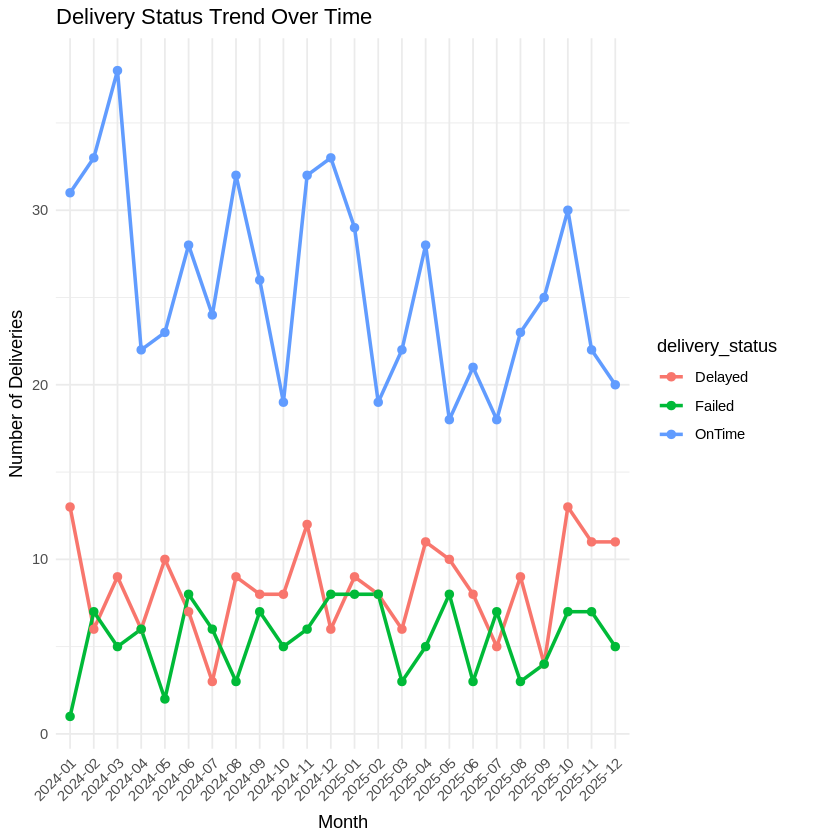

In [4]:
# Convert date columns to proper date format
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time,
                                        format="%Y-%m-%d %H:%M:%S")
orders$order_created_at  <- as.POSIXct(orders$order_created_at,
                                        format="%Y-%m-%d %H:%M:%S")

# Extract month and year
deliveries$month_year <- format(deliveries$dispatch_time, "%Y-%m")
orders$month_year     <- format(orders$order_created_at,  "%Y-%m")

# Delivery status trend over time
trend1 <- deliveries %>%
  group_by(month_year, delivery_status) %>%
  summarise(total=n(), .groups="drop") %>%
  filter(!is.na(month_year))

# Plot delivery trend
ggplot(trend1, aes(x=month_year, y=total,
                   color=delivery_status, group=delivery_status)) +
  geom_line(size=1) +
  geom_point(size=2) +
  labs(title="Delivery Status Trend Over Time",
       x="Month", y="Number of Deliveries") +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=45, hjust=1))

                            is_failed manual_route_override_count
is_failed                        1.00                        0.02
manual_route_override_count      0.02                        1.00
proof_of_completion_missing      0.17                        0.04
fuel_or_charge_cost              0.03                        0.11
route_distance_km               -0.03                        0.20
training_score                   0.07                        0.01
driver_rating                   -0.08                       -0.02
years_experience                 0.11                       -0.01
battery_health_pct              -0.04                        0.00
odometer_km                      0.00                        0.01
                            proof_of_completion_missing fuel_or_charge_cost
is_failed                                          0.17                0.03
manual_route_override_count                        0.04                0.11
proof_of_completion_missing                   

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded



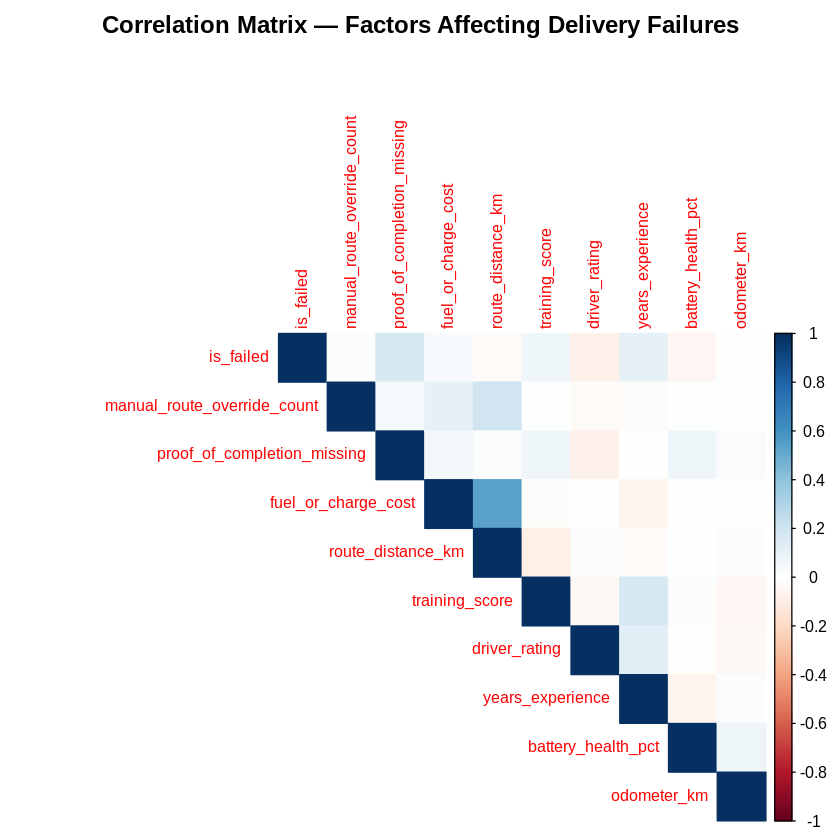

In [5]:
# Create numeric dataset for correlation
corr_data <- deliveries %>%
  left_join(drivers,  by="driver_id") %>%
  left_join(vehicles, by="vehicle_id") %>%
  mutate(is_failed = ifelse(delivery_status=="Failed", 1, 0)) %>%
  select(is_failed,
         manual_route_override_count,
         proof_of_completion_missing,
         fuel_or_charge_cost,
         route_distance_km,
         training_score,
         driver_rating,
         years_experience,
         battery_health_pct,
         odometer_km) %>%
  na.omit()

# Calculate correlation matrix
corr_matrix <- cor(corr_data)
print(round(corr_matrix, 2))

# Visualise correlation matrix
install.packages("corrplot")
library(corrplot)
corrplot(corr_matrix,
         method="color",
         type="upper",
         tl.cex=0.8,
         title="Correlation Matrix — Factors Affecting Delivery Failures",
         mar=c(0,0,2,0))

# A tibble: 8 × 13
  hub_name       zone      hub_type  capacity_score total_deliveries
  <chr>          <chr>     <chr>              <int>            <int>
1 East Dock      East      Warehouse             74              119
2 North Exchange North     Dispatch              82              136
3 South Link     South     Dispatch              78              106
4 Riverside Hub  Riverside Warehouse             66              115
5 West Gate      West      Dispatch              69              127
6 Midtown Relay  Central   Charging              63              128
7 Airport Hub    Airport   Dispatch              71              104
8 Central Core   Central   Control               88              115
  failure_rate delay_rate ontime_rate avg_rating avg_cost total_overrides
         <dbl>      <dbl>       <dbl>      <dbl>    <dbl>           <int>
1         9.24       19.3        71.4       3.9      12.7             106
2        12.5        19.1        68.4       3.84     12.8            

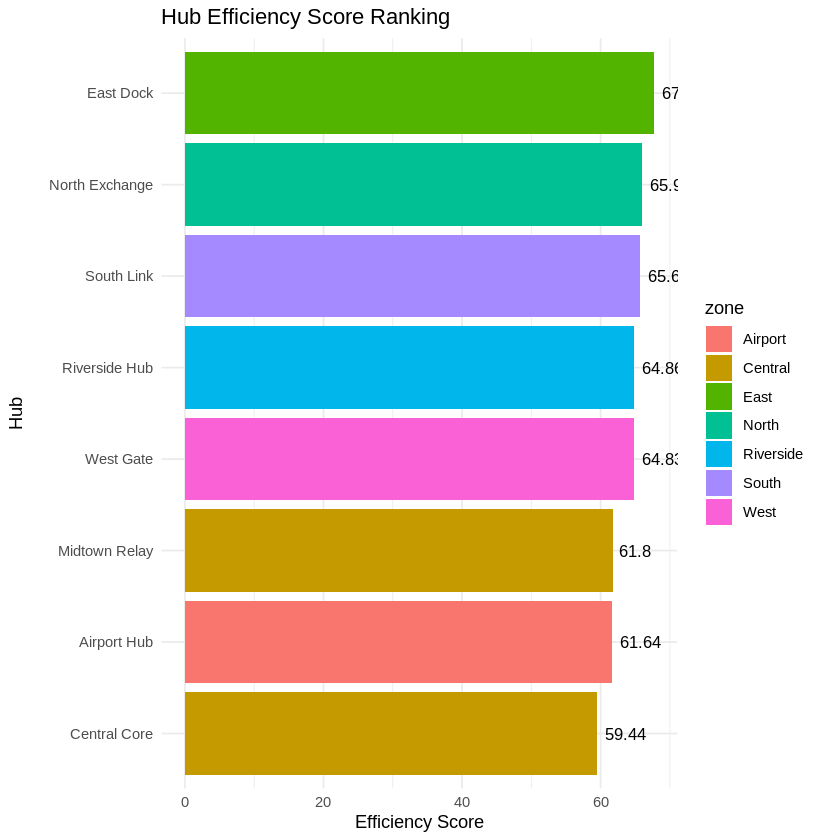

In [14]:
# Hub efficiency scoring — rank all hubs with a combined score
hub_scores <- deliveries %>%
  left_join(hubs, by="hub_id") %>%
  group_by(hub_name, zone, hub_type, capacity_score) %>%
  summarise(
    total_deliveries    = n(),
    failure_rate        = round(sum(delivery_status=="Failed") / n() * 100, 2),
    delay_rate          = round(sum(delivery_status=="Delayed") / n() * 100, 2),
    ontime_rate         = round(sum(delivery_status=="OnTime") / n() * 100, 2),
    avg_rating          = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2),
    avg_cost            = round(mean(fuel_or_charge_cost, na.rm=TRUE), 2),
    total_overrides     = sum(manual_route_override_count),
    missing_proof_pct   = round(sum(proof_of_completion_missing) / n() * 100, 2),
    .groups="drop"
  ) %>%
  mutate(
    efficiency_score = round(
      (ontime_rate * 0.4) +
      (avg_rating * 10 * 0.3) +
      ((100 - failure_rate) * 0.2) +
      ((100 - missing_proof_pct) * 0.1), 2)
  ) %>%
  arrange(desc(efficiency_score))

print(hub_scores)

# Visualise hub efficiency scores
ggplot(hub_scores, aes(x=reorder(hub_name, efficiency_score),
                       y=efficiency_score, fill=zone)) +
  geom_bar(stat="identity") +
  geom_text(aes(label=efficiency_score), hjust=-0.2, size=3.5) +
  coord_flip() +
  labs(title="Hub Efficiency Score Ranking",
       x="Hub", y="Efficiency Score") +
  theme_minimal()

In [16]:
driver_performance <- deliveries %>%
  mutate(delivery_status = trimws(tolower(delivery_status))) %>%
  group_by(driver_id) %>%
  summarise(
    total_deliveries = n(),
    success_rate = mean(delivery_status == "on-time", na.rm = TRUE)
  ) %>%
  arrange(desc(success_rate))

print(driver_performance)

# A tibble: 170 × 3
   driver_id total_deliveries success_rate
   <chr>                <int>        <dbl>
 1 D001                     6            0
 2 D002                     7            0
 3 D003                     4            0
 4 D004                     9            0
 5 D005                     5            0
 6 D006                     6            0
 7 D007                     2            0
 8 D008                     8            0
 9 D009                     5            0
10 D010                     7            0
# ℹ 160 more rows


In [22]:
vehicle_health <- deliveries %>%
  left_join(vehicles, by = "vehicle_id")

col_name <- tail(colnames(vehicle_health), 1)

vehicle_health <- vehicle_health %>%
  mutate(delivery_status = trimws(tolower(delivery_status))) %>%
  group_by(.data[[col_name]]) %>%
  summarise(
    total_deliveries = n(),
    failure_rate = mean(delivery_status %in% c("failed", "delayed"), na.rm = TRUE)
  ) %>%
  arrange(desc(failure_rate))

print(vehicle_health)

# A tibble: 4 × 3
  telematics_version total_deliveries failure_rate
  <chr>                         <int>        <dbl>
1 v1.9                            119        0.403
2 v2.2                            238        0.374
3 v2.0                            215        0.335
4 v2.1                            378        0.331


In [23]:
customer_segmentation <- customers %>%
  left_join(orders, by = "customer_id") %>%
  left_join(deliveries, by = "order_id") %>%
  mutate(delivery_status = trimws(tolower(delivery_status))) %>%
  group_by(customer_id) %>%
  summarise(
    total_orders = n(),
    failure_rate = mean(delivery_status %in% c("failed", "delayed"), na.rm = TRUE)
  )

print(customer_segmentation)

# A tibble: 650 × 3
   customer_id total_orders failure_rate
   <chr>              <int>        <dbl>
 1 C0001                  3        0.333
 2 C0002                  1        0    
 3 C0003                  1        0    
 4 C0004                  3        0.333
 5 C0005                  1        0    
 6 C0006                  3        0.333
 7 C0007                  1        0    
 8 C0008                  1        0    
 9 C0009                  1        1    
10 C0010                  4        0    
# ℹ 640 more rows


In [27]:
complaint_trend <- complaints %>%
  group_by(complaint_type) %>%
  summarise(total_complaints = n()) %>%
  arrange(desc(total_complaints))

print(complaint_trend)

# A tibble: 7 × 2
  complaint_type    total_complaints
  <chr>                        <int>
1 Delay                          101
2 MissedPickup                    64
3 AppIssue                        53
4 DriverBehaviour                 51
5 SupportExperience               20
6 Billing                         16
7 Damage                          15


In [31]:
app_performance <- app_events %>%
  group_by(event_type) %>%
  summarise(
    total_events = n()
  ) %>%
  arrange(desc(total_events))

print(app_performance)

# A tibble: 8 × 2
  event_type                  total_events
  <chr>                              <int>
1 track_order                          138
2 eta_refresh                          105
3 search_route                          99
4 chat_opened                           88
5 delivery_instruction_update           75
6 payment_retry                         69
7 chat_escalated                        38
8 cancel_attempt                        28


In [32]:
dashboard <- deliveries %>%
  mutate(delivery_status = tolower(trimws(delivery_status))) %>%
  summarise(
    total_deliveries = n(),
    on_time_rate = mean(delivery_status == "on-time", na.rm = TRUE),
    failure_rate = mean(delivery_status %in% c("failed", "delayed"), na.rm = TRUE)
  )

print(dashboard)

  total_deliveries on_time_rate failure_rate
1              950            0    0.3515789


In [34]:
write.csv(deliveries, "deliveries.csv", row.names = FALSE)
write.csv(corr_data, "corr_data.csv", row.names = FALSE)
write.csv(hub_scores, "hub_scores.csv", row.names = FALSE)
write.csv(driver_performance, "driver_performance.csv", row.names = FALSE)
write.csv(vehicle_health, "vehicle_health.csv", row.names = FALSE)
write.csv(customer_segmentation, "customer_segmentation.csv", row.names = FALSE)
write.csv(complaint_trend, "complaint_trend.csv", row.names = FALSE)
write.csv(dashboard, "dashboard_summary.csv", row.names = FALSE)